In [23]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
text = open('../input.txt').read()

In [3]:
len(text)

1115394

In [4]:
alph =  sorted(list(set(text)))
A = len(alph)
stoi = {c: i for i, c in enumerate(alph)}
itos = {v: k for k, v in stoi.items()}
print(A)
print(''.join(alph))

65

 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [5]:
encode = lambda x: [stoi[c] for c in x]
decode = lambda x: ''.join([itos[ic] for ic in x])

In [6]:
n = int(0.9 * len(text))
Xtr = encode(text[:n])
Xval = encode(text[n:])

In [7]:
block_size = 8
batch_size = 4
gen = torch.Generator().manual_seed(42)
def getbatch(X):
    starts = torch.randint(0, len(X) - block_size, (batch_size,), generator = gen)
    context = torch.tensor([X[st : st + block_size] for st in starts])
    target = torch.tensor([X[st + 1 : st + block_size + 1] for st in starts])
    return context, target

In [8]:
class Linear:

    def __init__(self, fan_in, fan_out, bias = True):
        self.weights = torch.randn((fan_in, fan_out), generator = gen) / (fan_in ** 0.5)
        self.bias = None if not bias else torch.zeros(fan_out)
    
    def __call__(self, x):
        x = x @ self.weights
        if self.bias is not None:
            x += self.bias
        self.out = x
        return self.out
    
    def parameters(self):
        return [self.weights] + ([] if self.bias is None else [self.bias])

In [9]:
class SelfAttentionHead:

    def __init__(self, fan_in, head_size):
        self.fan_in = fan_in
        self.head_size = head_size
        self.K = Linear(fan_in, head_size)
        self.Q = Linear(fan_in, head_size)
        self.V = Linear(fan_in, head_size)
    
    def forward(self, x):
        key = self.K(x)
        query = self.Q(x)
        value = self.V(x)
        Att = query @ key.transpose(-1, -2)
        normAtt = Att / (self.fan_in ** 0.5)
        trilAtt = torch.masked_fill(normAtt, torch.tril(normAtt) == 0, float('-inf'))
        smaxAtt = F.softmax(trilAtt, dim = -1)
        self.out = smaxAtt @ value
        return self.out
    
    def parameters(self):
        return self.K.parameters() + self.Q.parameters() + self.V.parameters()


In [10]:
class LayerNorm:

    def __init__(self, fan_in, eps = 1e-5):
        self.gamma = torch.ones(fan_in)
        self.beta = torch.zeros(fan_in)
        self.eps = eps
    
    def __call__(self, x):
        means = x.mean(-1, keepdim = True)
        vars = x.var(-1, keepdim = True)
        self.out = (x - means) / torch.sqrt(vars + self.eps) * self.gamma + self.beta
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

In [11]:
class GELU:

    def __call__(self, x):
        return F.gelu(x)
    
    def parameters(self):
        return []

In [12]:
class FeedForward:

    def __init__(self, fan_in, layer_size):
        self.lin1 = Linear(fan_in, layer_size)
        self.act1 = GELU()
        self.lin2 = Linear(layer_size, fan_in)
    
    def forward(self, x):
        self.out = self.lin2(self.act1(self.lin1(x)))
        return self.out
    
    def parameters(self):
        return self.lin1.parameters() + self.act1.parameters() + self.lin2.parameters()

In [13]:
class MultiHeadSelfAttention:
    
    def __init__(self, fan_in, head_size, num_head):
        self.heads = [SelfAttentionHead(fan_in, head_size) for _ in range(num_head)]
        self.proj = Linear(head_size * num_head, fan_in)
    
    def forward(self, x):
        self.out = torch.concat([head.forward(x) for head in self.heads], dim = -1)
        self.out = self.proj(self.out)
        return self.out

    def parameters(self):
        return [p for head in self.heads for p in head.parameters()] + self.proj.parameters()

In [14]:
class Block:

    def __init__(self, embed_size, head_size, num_head):
        self.norm1 = LayerNorm(embed_size)
        self.attn = MultiHeadSelfAttention(embed_size, head_size, num_head)
        self.norm2 = LayerNorm(embed_size)
        self.ff = FeedForward(embed_size, embed_size * 4)
    
    def forward(self, x):
        x = x + self.attn.forward(self.norm1(x))
        x = x + self.ff.forward(self.norm2(x))
        return x
    
    def parameters(self):
        return self.norm1.parameters() + self.attn.parameters() + self.norm2.parameters() + self.ff.parameters()


In [15]:
class Embedding:

    def __init__(self, num_embed, embed_size):
        self.embed_table = torch.randn((num_embed, embed_size), generator=gen)
    
    def __call__(self, x):
        self.out = self.embed_table[x]
        return self.out
    
    def parameters(self):
        return [self.embed_table]

In [16]:
class GPT:

    def __init__(self, alph_size, embed_size, head_size, num_head, num_blocks):
        self.embedding = Embedding(alph_size, embed_size)
        self.pos_embedding = Embedding(block_size, embed_size)
        self.blocks = [Block(embed_size, head_size, num_head) for _ in range(num_blocks)]
        self.linear = Linear(embed_size, alph_size)
    
    def forward(self, x):
        logits = self.embedding(x) + self.pos_embedding(torch.arange(block_size))
        for block in self.blocks:
            logits = block.forward(logits)
        logits = self.linear(logits)
        return logits
    
    @torch.no_grad()
    def generate(self, context, gen_len):
        text = context
        context = encode(context[-block_size:])
        for _ in range(gen_len):
            logits = self.forward(torch.tensor([context]))
            ix = torch.multinomial(F.softmax(logits[-1, -1], -1), generator=gen, num_samples=1).item()
            text += itos[ix]
            context = context[1:] + [ix]
        return text


    def parameters(self):
        return self.embedding.parameters() + self.pos_embedding.parameters() + [p for block in self.blocks for p in block.parameters()] + self.linear.parameters()

In [17]:
alph_size = A
embed_size = 10
head_size = 12
num_head = 2
num_blocks = 4
batch_size = 4

In [28]:
model = GPT(alph_size, embed_size, head_size, num_head, num_blocks)

In [29]:
model.generate('Hello, my name is ', 10)

'Hello, my name is gn;aMHfjwb'

In [30]:
params = model.parameters()
for p in params:
    p.requires_grad = True

In [31]:
lossi = []

In [43]:
@torch.no_grad()
def getloss(num):
    sum = 0
    for _ in range(num):
        context, target = getbatch(Xtr)
        logits = model.forward(context)
        sum += F.cross_entropy(logits.view(-1,alph_size), target.view(-1))
    return sum/num


In [44]:
epochs = 20000
lr = 1e-3
for e in range(epochs + 1):
    context, target = getbatch(Xtr)
    logits = model.forward(context)
    loss = F.cross_entropy(logits.view(-1,alph_size), target.view(-1))

    for p in params:
        p.grad = None
    
    loss.backward()

    for p in params:
        p.data += -lr * p.grad

    if e%1000 == 0:
        print(f'Epoch {e}/{epochs}, loss: {getloss(100)}')
    lossi.append(loss.item())

Epoch 0/20000, loss: 3.175797939300537
Epoch 1000/20000, loss: 3.159933567047119
Epoch 2000/20000, loss: 3.1587893962860107
Epoch 3000/20000, loss: 3.117680072784424
Epoch 4000/20000, loss: 3.1555821895599365
Epoch 5000/20000, loss: 3.081505537033081
Epoch 6000/20000, loss: 3.171121120452881
Epoch 7000/20000, loss: 3.103698492050171
Epoch 8000/20000, loss: 3.054697275161743
Epoch 9000/20000, loss: 3.086968421936035
Epoch 10000/20000, loss: 3.0983400344848633
Epoch 11000/20000, loss: 3.085005760192871
Epoch 12000/20000, loss: 2.9922876358032227
Epoch 13000/20000, loss: 2.9938805103302
Epoch 14000/20000, loss: 3.0252432823181152
Epoch 15000/20000, loss: 3.027470588684082
Epoch 16000/20000, loss: 2.978445053100586
Epoch 17000/20000, loss: 3.04296875
Epoch 18000/20000, loss: 2.9238991737365723
Epoch 19000/20000, loss: 2.9798903465270996
Epoch 20000/20000, loss: 2.921213388442993


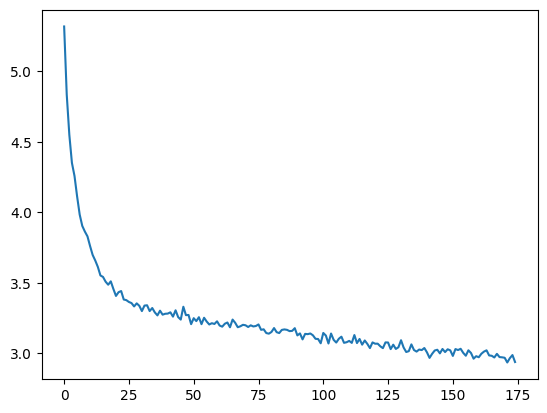

In [47]:
plt.plot(torch.tensor(lossi[1:]).view(-1, 200).mean(1))

In [48]:
model.generate('Hello, my name is ', 10)

'Hello, my name is t  thsen,a'